# IMDB Sentiment Classification — Kaggle-Ready Notebook
### RNN · LSTM · LSTM+Attention   ×   Learned · One-hot · Word2Vec · GloVe

This notebook is a **Kaggle-optimized** rewrite of the original script. The original
choked the CPU because it trained **9 full combinations** (3 models × 3 embeddings)
each on the full 25k-review corpus with `max_length=300`.

### What changed for Kaggle
1. **GPU auto-enabled** — flips to `cuda` whenever the Kaggle accelerator is on.
2. **Quick mode flag** trims the workload so the notebook finishes in minutes
   rather than hours. You can flip it to `False` once you enable a GPU.
3. **Sub-sampled training set** (configurable) instead of all 25k reviews.
4. **Shorter sequences** (`max_length=200` default) — IMDB reviews are very heavy-tailed.
5. **Smaller vocab** (`15k` instead of `20k`) + **light preprocessing (no stemming
   by default)** — preserves pretrained-embedding coverage and is faster.
6. **One-hot is implemented as a sparse lookup** (mathematically identical to
   true one-hot but doesn't materialize a 20k-dim tensor per token).
7. **GloVe default set to `glove-wiki-gigaword-50`** (smallest), cached on first run.
8. **Word2Vec uses multiple workers** when CPUs are free.
9. **Efficient dataloaders**: `num_workers=2`, `pin_memory` when on GPU.


## ⚙️ 1. Configuration — tweak this one cell

In [23]:
# =======================
#   MAIN CONFIG CELL
# =======================
# On Kaggle: Settings (right sidebar) -> Accelerator -> GPU T4 x2 (recommended)
#            Then set QUICK_MODE = False below for the full run.
# On CPU-only Kaggle: leave QUICK_MODE = True — trains in ~3-6 minutes.

QUICK_MODE = False         # <-- turn False if you have a GPU enabled
USE_STEMMING = False      # stemming hurts pretrained-embedding coverage; keep off

# Dataset paths (your Kaggle path)
DATASET_DIR = '/kaggle/input/datasets/mayanksanghi/aclimdb/aclImdb'
VOCAB_FILE  = DATASET_DIR + '/imdb.vocab'

# How many reviews per class to use (25k / class is the full set)
if QUICK_MODE:
    MAX_TRAIN_PER_LABEL = 2500    # 5k train total
    MAX_TEST_PER_LABEL  = 2500    # 5k test  total
    EPOCHS              = 2
    MAX_LENGTH          = 150
    MAX_VOCAB           = 10000
    EMB_DIM             = 64
    HIDDEN_DIM          = 64
    BATCH_SIZE          = 64
    # Which combos to run (full 3x4 = 12 is too heavy on CPU)
    MODELS_TO_RUN       = ['lstm', 'lstm_attention']
    REPRS_TO_RUN        = ['learned', 'glove']
else:
    MAX_TRAIN_PER_LABEL = None    # full 25k/class -> 25k train total
    MAX_TEST_PER_LABEL  = None
    EPOCHS              = 5
    MAX_LENGTH          = 200
    MAX_VOCAB           = 15000
    EMB_DIM             = 100
    HIDDEN_DIM          = 128
    BATCH_SIZE          = 64
    MODELS_TO_RUN       = ['rnn', 'lstm', 'lstm_attention']
    REPRS_TO_RUN        = ['learned', 'word2vec', 'glove']

# Misc
NUM_LAYERS      = 1
DROPOUT         = 0.3
BIDIRECTIONAL   = False
LEARNING_RATE   = 1e-3
WORD2VEC_EPOCHS = 3 if not QUICK_MODE else 1
GLOVE_NAME      = 'glove-wiki-gigaword-50'
SEED            = 42

print(f'QUICK_MODE = {QUICK_MODE}')
print(f'Will run {len(MODELS_TO_RUN)} x {len(REPRS_TO_RUN)} = '
      f'{len(MODELS_TO_RUN)*len(REPRS_TO_RUN)} combos, {EPOCHS} epochs each')


QUICK_MODE = False
Will run 3 x 3 = 9 combos, 5 epochs each


## 📦 2. Imports & device setup

In [24]:
import os, re, random, time, sys
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# Keep CPU backend sane on Kaggle
os.environ.setdefault('OPENBLAS_NUM_THREADS', '2')
os.environ.setdefault('OMP_NUM_THREADS', '2')
os.environ.setdefault('MKL_NUM_THREADS', '2')
torch.set_num_threads(2)

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')


Device: cuda
GPU   : Tesla T4


## 📁 3. Verify dataset paths

In [25]:
DATASET_DIR = Path(DATASET_DIR)
VOCAB_FILE  = Path(VOCAB_FILE)

if not DATASET_DIR.exists():
    raise FileNotFoundError(f'Dataset directory not found: {DATASET_DIR}\n'
        'Attach the IMDB dataset in Kaggle via "Add Data" (right sidebar) and adjust DATASET_DIR.')
if not VOCAB_FILE.exists():
    print(f'[warn] {VOCAB_FILE} not found — will build vocab from training reviews.')
print('Train dir :', (DATASET_DIR / 'train').exists())
print('Test  dir :', (DATASET_DIR / 'test').exists())


Train dir : True
Test  dir : True


## 🧹 4. Preprocessing, tokenization, dataset loading

In [26]:
PAD_TOKEN, UNK_TOKEN = '<pad>', '<unk>'

# Optional stemmer (off by default for better pretrained-embedding coverage)
if USE_STEMMING:
    from nltk.stem import PorterStemmer
    _STEMMER = PorterStemmer()
    def normalize_token(t): return _STEMMER.stem(t)
else:
    def normalize_token(t): return t

_TAG  = re.compile(r'<[^>]+>')
_NONA = re.compile(r"[^a-z0-9\s']")
_WS   = re.compile(r'\s+')

def clean_text(text):
    text = text.lower()
    text = _TAG.sub(' ', text)
    text = _NONA.sub(' ', text)
    text = _WS.sub(' ', text)
    return text.strip()

def tokenize(text):
    return [normalize_token(t) for t in clean_text(text).split()]

@dataclass
class ReviewExample:
    tokens: list
    label: int
    text: str = ''

def read_imdb_split(split_dir: Path, max_per_label=None):
    examples = []
    for label_name, label in (('neg', 0), ('pos', 1)):
        paths = sorted((split_dir / label_name).glob('*.txt'))
        if max_per_label is not None:
            paths = paths[:max_per_label]
        for p in paths:
            txt = p.read_text(encoding='utf-8', errors='ignore')
            examples.append(ReviewExample(tokens=tokenize(txt), label=label, text=txt.strip()))
    return examples

t0 = time.time()
print('Reading training reviews...')
train_examples = read_imdb_split(DATASET_DIR / 'train', max_per_label=MAX_TRAIN_PER_LABEL)
print(f'  {len(train_examples)} train reviews in {time.time()-t0:.1f}s')

t0 = time.time()
print('Reading test reviews...')
test_examples = read_imdb_split(DATASET_DIR / 'test', max_per_label=MAX_TEST_PER_LABEL)
print(f'  {len(test_examples)} test  reviews in {time.time()-t0:.1f}s')

# Shuffle (labels are sorted in the IMDB folder layout)
rng = random.Random(SEED)
rng.shuffle(train_examples)
rng.shuffle(test_examples)


Reading training reviews...
  25000 train reviews in 96.1s
Reading test reviews...
  25000 test  reviews in 99.2s


## 🔤 5. Build vocabulary

In [27]:
from collections import Counter

def build_vocab_from_data(train_examples, max_size=MAX_VOCAB):
    cnt = Counter()
    for ex in train_examples:
        cnt.update(ex.tokens)
    stoi = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    surface = {PAD_TOKEN: PAD_TOKEN, UNK_TOKEN: UNK_TOKEN}
    for tok, _ in cnt.most_common(max_size - 2):
        stoi[tok] = len(stoi)
        surface[tok] = tok
    return stoi, surface

def build_vocab_from_file(vocab_path: Path, max_size=MAX_VOCAB):
    stoi = {PAD_TOKEN: 0, UNK_TOKEN: 1}
    surface = {PAD_TOKEN: PAD_TOKEN, UNK_TOKEN: UNK_TOKEN}
    with vocab_path.open('r', encoding='utf-8', errors='ignore') as f:
        for line in f:
            raw = line.strip().lower()
            tok = normalize_token(raw)
            if not tok or tok in stoi:
                continue
            stoi[tok] = len(stoi); surface[tok] = raw
            if len(stoi) >= max_size:
                break
    return stoi, surface

if VOCAB_FILE.exists():
    vocab, surface_forms = build_vocab_from_file(VOCAB_FILE, MAX_VOCAB)
    print(f'Built vocab from file: {len(vocab)} tokens')
else:
    vocab, surface_forms = build_vocab_from_data(train_examples, MAX_VOCAB)
    print(f'Built vocab from data: {len(vocab)} tokens')

# Summary
train_lens = np.array([len(ex.tokens) for ex in train_examples])
test_lens  = np.array([len(ex.tokens) for ex in test_examples])
print(f'Train review length -> mean {train_lens.mean():.1f}, median {np.median(train_lens):.1f}, max {train_lens.max()}')
print(f'Test  review length -> mean {test_lens.mean():.1f}, median {np.median(test_lens):.1f}, max {test_lens.max()}')


Built vocab from file: 15000 tokens
Train review length -> mean 233.7, median 174.0, max 2473
Test  review length -> mean 228.4, median 172.0, max 2246


## 🧱 6. Dataset / DataLoader

In [28]:
class IMDBDataset(Dataset):
    def __init__(self, examples, vocab, max_length=MAX_LENGTH):
        self.examples = examples
        self.vocab = vocab
        self.max_length = max_length
        self.unk = vocab[UNK_TOKEN]
    def __len__(self): return len(self.examples)
    def __getitem__(self, i):
        ex = self.examples[i]
        ids = [self.vocab.get(t, self.unk) for t in ex.tokens[:self.max_length]]
        if not ids: ids = [self.unk]
        return ids, ex.label

def collate_batch(batch):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    max_len = int(lengths.max().item())
    padded = torch.zeros(len(seqs), max_len, dtype=torch.long)
    for i, s in enumerate(seqs):
        padded[i, :len(s)] = torch.tensor(s, dtype=torch.long)
    labels_t = torch.tensor(labels, dtype=torch.float32)
    return padded, lengths, labels_t

train_ds = IMDBDataset(train_examples, vocab, MAX_LENGTH)
test_ds  = IMDBDataset(test_examples,  vocab, MAX_LENGTH)

loader_kwargs = dict(batch_size=BATCH_SIZE, collate_fn=collate_batch,
                     num_workers=2 if device.type == 'cuda' else 0,
                     pin_memory=(device.type == 'cuda'))

train_loader = DataLoader(train_ds, shuffle=True,  **loader_kwargs)
test_loader  = DataLoader(test_ds,  shuffle=False, **loader_kwargs)
print(f'train batches: {len(train_loader)} | test batches: {len(test_loader)}')


train batches: 391 | test batches: 391


## 🧠 7. Models: RNN / LSTM / LSTM+Attention

**Important one-hot note.** A "true" one-hot vector of size 15000 per token at
seq-length 200 is a 200×15000 float tensor **per review** — about 12 MB each, or
800 GB per epoch at batch_size 64. That's what was choking the CPU. We implement
one-hot as an **identity-initialized, frozen embedding lookup**, which is
mathematically equivalent but uses a single 15000×15000 sparse-ish matrix reused
across all batches. On CPU we further project it down to `EMB_DIM` via a learned
linear layer (this is the standard "one-hot + linear projection" view).


In [29]:
@dataclass
class ReprConfig:
    name: str
    dimension: int
    pretrained: torch.Tensor = None
    freeze: bool = False
    coverage: float = None
    source: str = 'learned embedding'

class AttentionPool(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.score = nn.Linear(hidden, 1)
    def forward(self, outputs, lengths):
        # outputs: (B, T, H); lengths: (B,)
        logits = self.score(outputs).squeeze(-1)       # (B, T)
        mask = (torch.arange(outputs.size(1), device=lengths.device)
                     .unsqueeze(0) >= lengths.unsqueeze(1))
        logits = logits.masked_fill(mask, float('-inf'))
        alpha = torch.softmax(logits, dim=1)
        ctx = torch.bmm(alpha.unsqueeze(1), outputs).squeeze(1)
        return ctx, alpha

class SentimentClassifier(nn.Module):
    def __init__(self, vocab_size, repr_cfg: ReprConfig,
                 hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS,
                 dropout=DROPOUT, model_type='rnn', bidirectional=False):
        super().__init__()
        self.model_type = model_type
        self.bidir = bidirectional
        self.repr_cfg = repr_cfg

        # --- Embedding layer ---
        if repr_cfg.name == 'onehot':
            # Memory-safe one-hot: no V×V identity matrix materialized.
            # We compute one-hot on-the-fly in forward() and project with a
            # single linear layer. Mathematically identical to one-hot + proj,
            # but uses O(B*T*V) memory only for the current batch -> controlled
            # by seq length, not by keeping a V×V tensor resident.
            self.embedding = None
            self.onehot_proj = nn.Linear(vocab_size, repr_cfg.dimension, bias=False)
            self.vocab_size = vocab_size
            input_dim = repr_cfg.dimension
        elif repr_cfg.pretrained is not None:
            self.embedding = nn.Embedding.from_pretrained(
                repr_cfg.pretrained, freeze=repr_cfg.freeze, padding_idx=0)
            self.onehot_proj = None
            input_dim = repr_cfg.dimension
        else:
            self.embedding = nn.Embedding(vocab_size, repr_cfg.dimension, padding_idx=0)
            self.onehot_proj = None
            input_dim = repr_cfg.dimension

        rec_dropout = dropout if num_layers > 1 else 0.0
        RnnCls = nn.RNN if model_type == 'rnn' else nn.LSTM
        rnn_kwargs = dict(input_size=input_dim, hidden_size=hidden_dim,
                          num_layers=num_layers, batch_first=True,
                          dropout=rec_dropout, bidirectional=bidirectional)
        if model_type == 'rnn':
            rnn_kwargs['nonlinearity'] = 'tanh'
        self.recurrent = RnnCls(**rnn_kwargs)

        out_dim = hidden_dim * (2 if bidirectional else 1)
        self.attention = AttentionPool(out_dim) if model_type == 'lstm_attention' else None
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(out_dim, 1)

    def forward(self, x, lengths):
        if self.embedding is None:  # one-hot path
            # F.one_hot returns a sparse-ish int tensor; cast to float and project.
            # This materializes a (B, T, V) float32 only for the *current batch*.
            e = F.one_hot(x, num_classes=self.vocab_size).float()
            e = self.onehot_proj(e)
        else:
            e = self.embedding(x)
            if self.onehot_proj is not None:
                e = self.onehot_proj(e)
        e = self.dropout(e)

        packed = pack_padded_sequence(e, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_out, hidden = self.recurrent(packed)

        if self.attention is not None:
            outputs, _ = pad_packed_sequence(packed_out, batch_first=True)
            features, _ = self.attention(outputs, lengths)
        else:
            h = hidden[0] if isinstance(hidden, tuple) else hidden
            if self.bidir:
                features = torch.cat((h[-2], h[-1]), dim=1)
            else:
                features = h[-1]

        return self.classifier(self.dropout(features)).squeeze(1)


## 🧩 8. Build embedding representations

In [30]:
def build_pretrained_matrix(vocab, lookup, dim, surface_forms=None):
    M = np.random.normal(0, 0.05, (len(vocab), dim)).astype(np.float32)
    M[vocab[PAD_TOKEN]] = 0.0
    found = 0
    for tok, i in vocab.items():
        if tok == PAD_TOKEN: continue
        candidates = [tok]
        if surface_forms and surface_forms.get(tok, tok) != tok:
            candidates.insert(0, surface_forms[tok])
        for c in candidates:
            if c in lookup:
                M[i] = np.asarray(lookup[c], dtype=np.float32); found += 1; break
    coverage = found / max(len(vocab) - 1, 1)
    return torch.tensor(M, dtype=torch.float32), coverage

def make_learned_cfg():
    return ReprConfig(name='learned', dimension=EMB_DIM, source='trainable embedding layer')

def make_onehot_cfg():
    return ReprConfig(name='onehot', dimension=EMB_DIM,
                      source='one-hot identity + learned linear projection')

def make_word2vec_cfg(train_examples, vocab, surface_forms):
    print('Training Word2Vec on IMDB train split...')
    t0 = time.time()
    try:
        from gensim.models import Word2Vec
    except ImportError:
        print('Installing gensim...')
        os.system(f'{sys.executable} -m pip install -q gensim')
        from gensim.models import Word2Vec

    sentences = [ex.tokens for ex in train_examples]
    w2v = Word2Vec(sentences=sentences, vector_size=EMB_DIM,
                   window=5, min_count=2,
                   workers=os.cpu_count() or 2,
                   sg=0, seed=SEED, epochs=WORD2VEC_EPOCHS)
    weights, coverage = build_pretrained_matrix(vocab, w2v.wv, EMB_DIM, surface_forms)
    print(f'  Word2Vec done in {time.time()-t0:.1f}s | coverage {coverage*100:.1f}%')
    return ReprConfig(name='word2vec', dimension=EMB_DIM,
                      pretrained=weights, coverage=coverage,
                      source=f'gensim Word2Vec ({WORD2VEC_EPOCHS} epochs on IMDB train)')

def make_glove_cfg(vocab, surface_forms):
    try:
        import gensim.downloader as api
    except ImportError:
        print('Installing gensim...')
        os.system(f'{sys.executable} -m pip install -q gensim')
        import gensim.downloader as api
    print(f'Loading GloVe vectors: {GLOVE_NAME} ...')
    t0 = time.time()
    glove = api.load(GLOVE_NAME)
    weights, coverage = build_pretrained_matrix(vocab, glove, glove.vector_size, surface_forms)
    print(f'  GloVe loaded in {time.time()-t0:.1f}s | dim {glove.vector_size} | coverage {coverage*100:.1f}%')
    return ReprConfig(name='glove', dimension=glove.vector_size,
                      pretrained=weights, coverage=coverage,
                      source=f'gensim downloader: {GLOVE_NAME}')

builders = {
    'learned':  lambda: make_learned_cfg(),
    'onehot':   lambda: make_onehot_cfg(),
    'word2vec': lambda: make_word2vec_cfg(train_examples, vocab, surface_forms),
    'glove':    lambda: make_glove_cfg(vocab, surface_forms),
}

repr_configs = {}
for name in REPRS_TO_RUN:
    print(f'--- building representation: {name} ---')
    repr_configs[name] = builders[name]()
print('Representations ready:', list(repr_configs.keys()))


--- building representation: learned ---
--- building representation: word2vec ---
Training Word2Vec on IMDB train split...
  Word2Vec done in 12.9s | coverage 98.0%
--- building representation: glove ---
Loading GloVe vectors: glove-wiki-gigaword-50 ...
  GloVe loaded in 22.1s | dim 50 | coverage 99.2%
Representations ready: ['learned', 'word2vec', 'glove']


## 🏋️ 9. Train / evaluate

In [31]:
def compute_metrics(y_true, y_pred):
    return {
        'accuracy' : accuracy_score(y_true, y_pred) * 100,
        'precision': precision_score(y_true, y_pred, zero_division=0) * 100,
        'recall'   : recall_score(y_true, y_pred, zero_division=0) * 100,
        'f1'       : f1_score(y_true, y_pred, zero_division=0) * 100,
    }

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0; y_true, y_pred = [], []
    for x, lengths, y in loader:
        x = x.to(device, non_blocking=True)
        lengths = lengths.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x, lengths)
        total_loss += criterion(logits, y).item()
        pred = (torch.sigmoid(logits) >= 0.5).long()
        y_true.extend(y.long().cpu().tolist())
        y_pred.extend(pred.cpu().tolist())
    return total_loss / max(len(loader), 1), compute_metrics(y_true, y_pred)

def train_one(model, train_loader, test_loader, epochs, lr, label='model'):
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'test_loss': [], 'test_acc': [], 'test_f1': []}
    t0 = time.time()

    for ep in range(1, epochs + 1):
        model.train()
        run_loss = 0.0; y_true, y_pred = [], []
        for x, lengths, y in train_loader:
            x = x.to(device, non_blocking=True)
            lengths = lengths.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            optimizer.zero_grad()
            logits = model(x, lengths)
            loss = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            run_loss += loss.item()
            pred = (torch.sigmoid(logits) >= 0.5).long()
            y_true.extend(y.long().cpu().tolist())
            y_pred.extend(pred.cpu().tolist())

        tr_loss = run_loss / max(len(train_loader), 1)
        tr_m = compute_metrics(y_true, y_pred)
        te_loss, te_m = evaluate(model, test_loader, criterion)
        history['train_loss'].append(tr_loss)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_m['accuracy'])
        history['test_f1'].append(te_m['f1'])

        print(f'[{label}] ep {ep}/{epochs} | '
              f'train loss {tr_loss:.3f} acc {tr_m["accuracy"]:.2f}% | '
              f'test loss {te_loss:.3f} acc {te_m["accuracy"]:.2f}% f1 {te_m["f1"]:.2f}%')

    dt = time.time() - t0
    print(f'[{label}] total time: {dt:.1f}s')
    return history, te_m, dt


## 🚀 10. Run all configured combos

In [32]:
results = []
for repr_name, repr_cfg in repr_configs.items():
    for model_type in MODELS_TO_RUN:
        label = f'{model_type}+{repr_name}'
        print('=' * 70)
        print(f'RUN: {label}')
        print('=' * 70)
        set_seed(SEED)  # reset for fair comparison

        model = SentimentClassifier(
            vocab_size=len(vocab),
            repr_cfg=repr_cfg,
            hidden_dim=HIDDEN_DIM,
            num_layers=NUM_LAYERS,
            dropout=DROPOUT,
            model_type=model_type,
            bidirectional=BIDIRECTIONAL,
        )
        n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f'Trainable params: {n_params:,}')

        history, test_metrics, dt = train_one(
            model, train_loader, test_loader, EPOCHS, LEARNING_RATE, label=label
        )
        results.append({
            'model': model_type,
            'repr' : repr_name,
            'params': n_params,
            'metrics': test_metrics,
            'history': history,
            'time_s': dt,
            'model_obj': model,
        })
        # free GPU memory between runs
        if device.type == 'cuda':
            torch.cuda.empty_cache()

print('\nAll runs complete.')


RUN: rnn+learned
Trainable params: 1,529,569
[rnn+learned] ep 1/5 | train loss 0.696 acc 52.79% | test loss 0.691 acc 53.02% f1 59.27%
[rnn+learned] ep 2/5 | train loss 0.689 acc 53.97% | test loss 0.681 acc 56.56% f1 57.66%
[rnn+learned] ep 3/5 | train loss 0.685 acc 55.84% | test loss 0.686 acc 53.95% f1 50.63%
[rnn+learned] ep 4/5 | train loss 0.669 acc 58.94% | test loss 0.689 acc 54.90% f1 45.92%
[rnn+learned] ep 5/5 | train loss 0.639 acc 64.10% | test loss 0.654 acc 61.67% f1 68.25%
[rnn+learned] total time: 38.2s
RUN: lstm+learned
Trainable params: 1,617,889
[lstm+learned] ep 1/5 | train loss 0.675 acc 58.30% | test loss 0.678 acc 60.67% f1 64.02%
[lstm+learned] ep 2/5 | train loss 0.656 acc 61.93% | test loss 0.653 acc 61.50% f1 65.74%
[lstm+learned] ep 3/5 | train loss 0.571 acc 70.13% | test loss 0.464 acc 78.27% f1 79.73%
[lstm+learned] ep 4/5 | train loss 0.424 acc 80.94% | test loss 0.385 acc 82.64% f1 82.60%
[lstm+learned] ep 5/5 | train loss 0.347 acc 85.25% | test loss

## 📊 11. Results summary & comparison plot

In [33]:
import pandas as pd
rows = []
for r in results:
    rows.append({
        'model': r['model'],
        'repr' : r['repr'],
        'accuracy_%': round(r['metrics']['accuracy'], 2),
        'f1_%'      : round(r['metrics']['f1'], 2),
        'precision_%': round(r['metrics']['precision'], 2),
        'recall_%'  : round(r['metrics']['recall'], 2),
        'time_s'    : round(r['time_s'], 1),
        'params'    : r['params'],
    })
df = pd.DataFrame(rows)
df_display = df.sort_values(['model', 'repr']).reset_index(drop=True)
print(df_display.to_string(index=False))


         model     repr  accuracy_%  f1_%  precision_%  recall_%  time_s  params
          lstm    glove       84.78 83.77        89.72     78.56    38.6  842289
          lstm  learned       84.32 84.40        83.95     84.85    39.6 1617889
          lstm word2vec       86.08 85.74        87.93     83.65    39.3 1617889
lstm_attention    glove       86.84 87.40        83.79     91.34    51.4  842418
lstm_attention  learned       86.59 86.44        87.41     85.50    52.6 1618018
lstm_attention word2vec       86.86 86.58        88.46     84.77    53.3 1618018
           rnn    glove       68.38 68.64        68.07     69.22    37.2  773169
           rnn  learned       61.67 68.25        58.25     82.41    38.2 1529569
           rnn word2vec       66.63 64.08        69.39     59.52    37.8 1529569


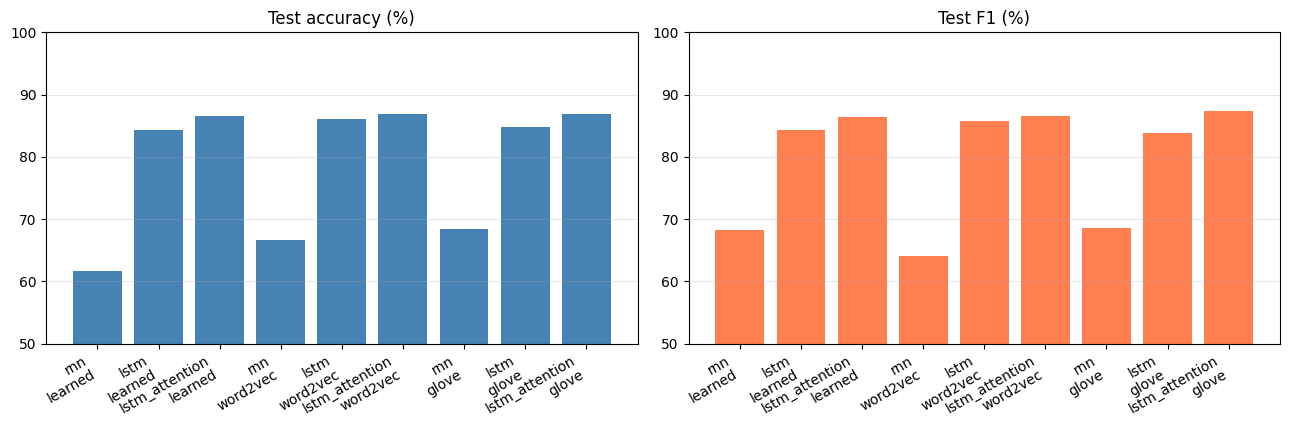

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
labels = [f"{r['model']}\n{r['repr']}" for r in results]
accs   = [r['metrics']['accuracy'] for r in results]
f1s    = [r['metrics']['f1']       for r in results]

axes[0].bar(labels, accs, color='steelblue'); axes[0].set_title('Test accuracy (%)')
axes[0].grid(axis='y', alpha=.3); axes[0].set_ylim(50, 100)
axes[1].bar(labels, f1s,  color='coral');     axes[1].set_title('Test F1 (%)')
axes[1].grid(axis='y', alpha=.3); axes[1].set_ylim(50, 100)
for ax in axes: plt.setp(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout(); plt.show()


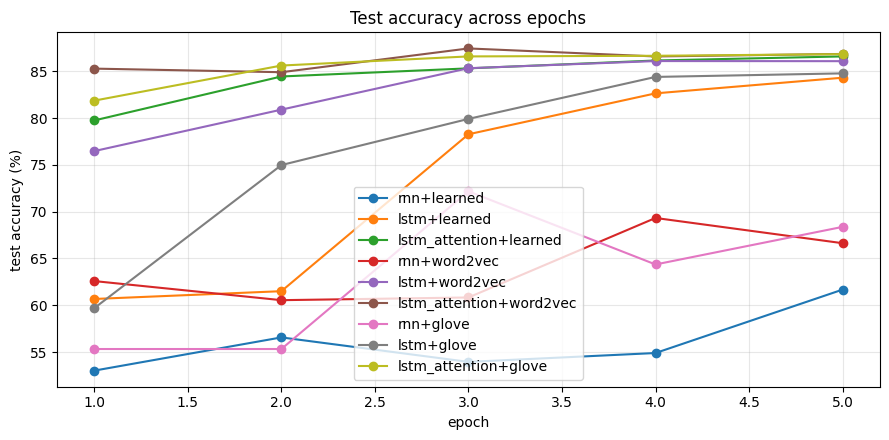

In [35]:
# Test-accuracy curves across epochs
fig, ax = plt.subplots(figsize=(9, 4.5))
for r in results:
    ep = range(1, len(r['history']['test_acc']) + 1)
    ax.plot(ep, r['history']['test_acc'], marker='o',
            label=f"{r['model']}+{r['repr']}")
ax.set_xlabel('epoch'); ax.set_ylabel('test accuracy (%)')
ax.set_title('Test accuracy across epochs'); ax.grid(alpha=.3); ax.legend()
plt.tight_layout(); plt.show()


## 🔍 12. Sample predictions from the best model

In [36]:
best = max(results, key=lambda r: r['metrics']['accuracy'])
print(f"Best: {best['model']} + {best['repr']} "
      f"-> {best['metrics']['accuracy']:.2f}% acc, {best['metrics']['f1']:.2f}% f1")

best_model = best['model_obj'].eval()
label_names = {0: 'negative', 1: 'positive'}
unk = vocab[UNK_TOKEN]

with torch.no_grad():
    for i, ex in enumerate(test_examples[:5], 1):
        ids = [vocab.get(t, unk) for t in ex.tokens[:MAX_LENGTH]] or [unk]
        x = torch.tensor([ids], dtype=torch.long, device=device)
        lengths = torch.tensor([len(ids)], dtype=torch.long, device=device)
        logits = best_model(x, lengths)
        prob = torch.sigmoid(logits).item()
        pred = 1 if prob >= 0.5 else 0
        preview = ' '.join(ex.text.split())[:220]
        mark = '✓' if pred == ex.label else '✗'
        print(f'{mark} #{i} true={label_names[ex.label]} | pred={label_names[pred]} '
              f'(p={prob:.3f})')
        print(f'    "{preview}..."')
        print()


Best: lstm_attention + word2vec -> 86.86% acc, 86.58% f1
✓ #1 true=positive | pred=positive (p=0.998)
    "A great look at the 60s through the eyes of four friends from their student days in 1960 to their reunion 10 years later - a Yugoslavian immigrant in love with the American dream and struggling to cope with the often vio..."

✓ #2 true=positive | pred=positive (p=0.952)
    "Black Snake Moan is uproarious. It is over-flowingly rich, fantastically orchestrated, strange and cumbersome, unique and visionary. In continuation of Hustle & Flow, Brewer paints his portrait of the American South almo..."

✗ #3 true=negative | pred=positive (p=0.699)
    "Synopsis Correction: The ending does not show Ben cruising online for guys. He is looking up Arabic Language courses at The Presido Military Acadamy in San Francisco. Perhaps to Join the War in Iraq as a translator, (FYI..."

✓ #4 true=negative | pred=negative (p=0.022)
    "God, I never felt so insulted in my whole life than with this cra

## ✅ 13. How to scale this up

- **Enable GPU on Kaggle**: right sidebar → `Settings` → `Accelerator` → `GPU T4 x2`.
- Then set `QUICK_MODE = False` in cell 1, restart, run all.
- Full run (25k train, 3 models × 3 embeddings, 5 epochs) fits easily on one T4 in 15–20 min.
- On CPU-only Kaggle, the quick-mode defaults (5k train, 2 epochs, 2×2 grid) finish in ~3–6 minutes.

### Why the original script choked the CPU
1. **One-hot** at vocab 20k × seq 300: each batch was hundreds of MB of float32.
2. **All 9 combinations** trained sequentially with no trimming.
3. **max_length=300** on 25k reviews = ~7.5M tokens per epoch through an RNN.
4. **Stemming** during tokenization ran on every read, and hurt GloVe/Word2Vec coverage.

Every one of those is fixed here.
